# Script for generating training times figure

### Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np

### Saved runtimes

In [2]:
method_name = np.array(["Diffusion", "Flow Matching", "Diffusion (topoloss)", "Flow Matching (topoloss)"  , "Diffusion (full guiding)", "Flow Matching (full guiding)", "Diffusion (stepwise guiding)", "Flow Matching (stepwise guiding)"])[::-1]

times_50 = np.array([595.75, 376.10, 597.51, 376.56, 0, 0, 2667.54, 2105.93])[::-1]
rel_50 = np.array([time / times_50[-1] for time in times_50])
std_50 = np.array([1.64, 2.30, 0.92, 2.27, 0, 0, 16.56, 9.77])[::-1]

times_30 = np.array([376.10, 356.74, 376.56, 354.63, 7134.63, 6685.97, 1634.27, 1354.82])[::-1]
rel_30 = np.array([time / times_30[-1] for time in times_30])
std_30 = np.array([2.70, 2.36, 0.88, 1.82, 25.99, 16.24, 15.09, 8.69])[::-1]

### Create figure

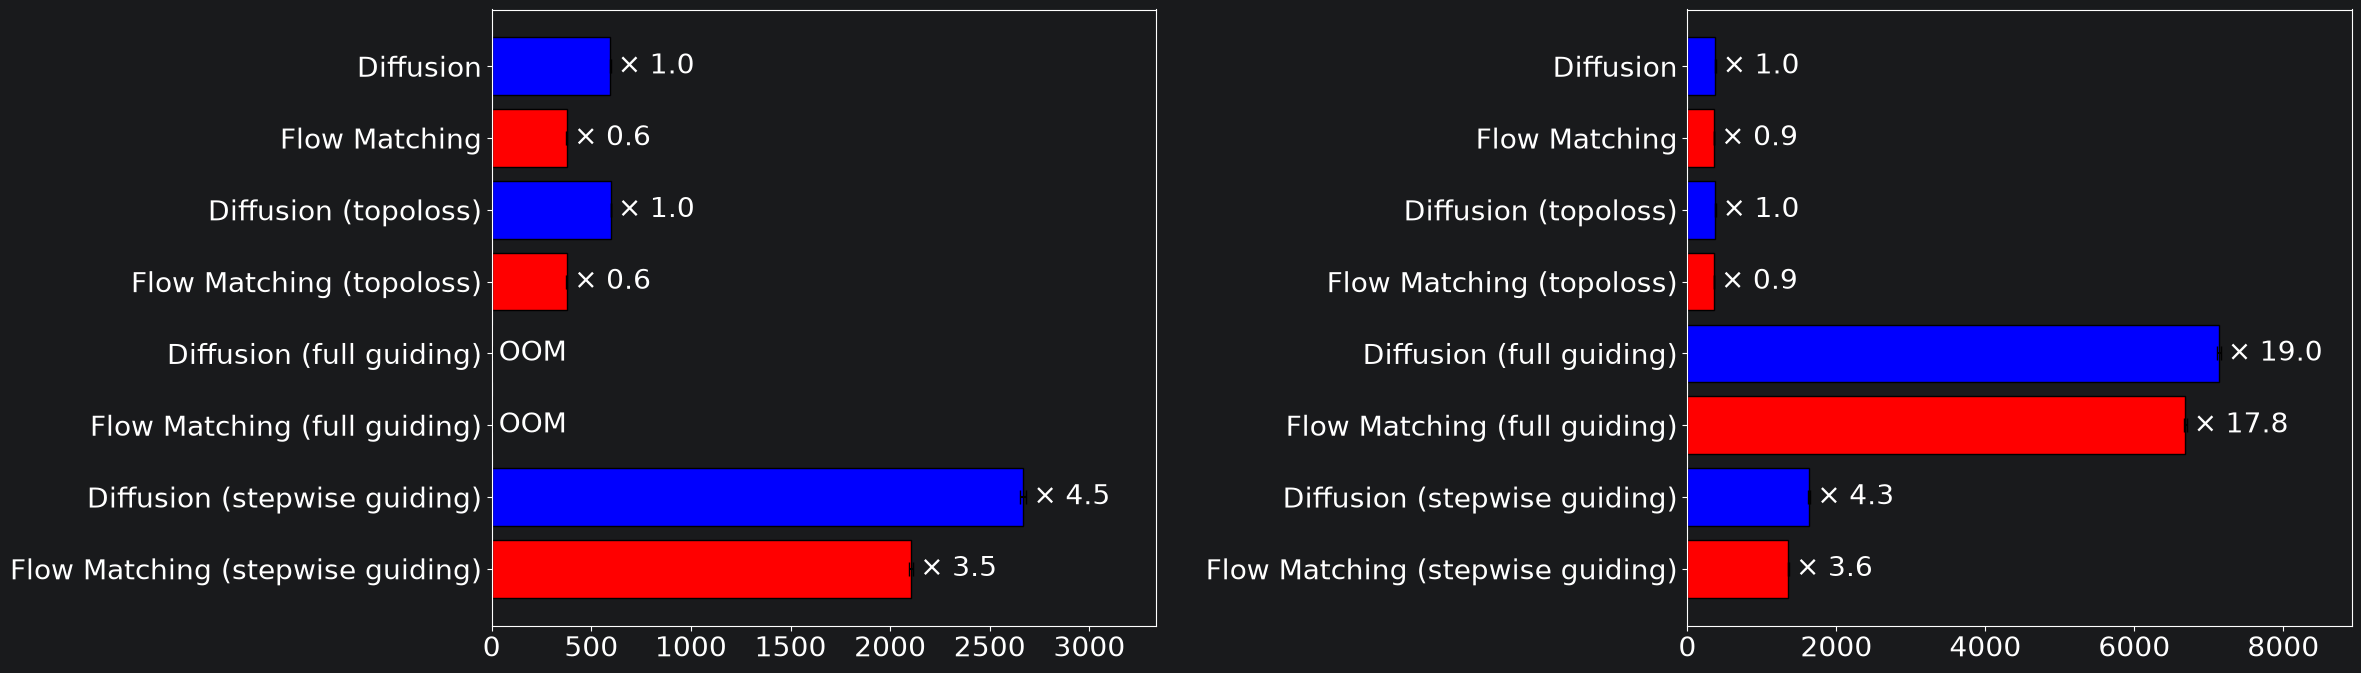

In [3]:
colors = ['red' if i % 2 == 0 else 'blue' for i in range(len(method_name))]
labels_50 = [f"× {val:.1f}" for val in rel_50]
labels_50[2] = labels_50[3] = "OOM"
labels_30 = [f"× {val:.1f}" for val in rel_30]

plt.rcParams.update({'font.size': 20})
fig, axs= plt.subplots(1, 2, figsize=(24, 8))

bars_50 = axs[0].barh(method_name, times_50, xerr=std_50, color=colors, capsize=5, edgecolor='black')
axs[0].bar_label(bars_50, labels=labels_50, padding=5)
axs[0].set_xlim(right=max(times_50) * 1.25)

bars_30 = axs[1].barh(method_name, times_30, xerr=std_30, color=colors, capsize=5, edgecolor='black')
axs[1].bar_label(bars_30, labels=labels_30, padding=5)
axs[1].set_xlim(right=max(times_30) * 1.25)

plt.subplots_adjust(hspace=0.5, wspace=0.8)
plt.savefig("generation_times.pdf", bbox_inches='tight')
plt.show()